In [1]:

!git clone https://github.com/tsegabogale24/brent_crude_analysis
%cd brent_crude_analysis

Cloning into 'brent_crude_analysis'...
remote: Enumerating objects: 44, done.
remote: Counting objects: 100% (44/44), done.
remote: Compressing objects: 100% (31/31), done.
remote: Total 44 (delta 11), reused 37 (delta 9), pack-reused 0 (from 0)
Receiving objects: 100% (44/44), 720.05 KiB | 2.32 MiB/s, done.
Resolving deltas: 100% (11/11), done.
/content/brent_crude_analysis


In [2]:
!pip install -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 5.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 9.0 MB/s eta 0:00:00
ERROR: Ignored the following versions that require a different python version: 1.21.2 Requires-Python >=3.7,<3.11; 1.21.3 Requires-Python >=3.7,<3.11; 1.21.4 Requires-Python >=3.7,<3.11; 1.21.5 Requires-Python >=3.7,<3.11; 1.21.6 Requires-Python >=3.7,<3.11
ERROR: Could not find a version that satisfies the requirement pywin32==311 (from versions: none)
ERROR: No matching distribution found for pywin32==311


In [3]:
!pip install pymc ruptures yfinance

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 19.3 MB/s eta 0:00:00


In [4]:
from google.colab import files
uploaded = files.upload()


Saving BrentOilPrices.csv to BrentOilPrices.csv


In [5]:
import pandas as pd

df = pd.read_csv("BrentOilPrices.csv")

In [17]:
from scripts.brent_change_point_analysis import *

# Define the bayesian_change_point_model function directly in the notebook
def bayesian_change_point_model(log_returns, dates):
    """
    Performs Bayesian change point analysis on log returns.

    Args:
        log_returns (np.ndarray): Array of log returns.
        dates (pd.Index): Datetime index corresponding to log returns.

    Returns:
        tuple: A tuple containing:
            - pd.Timestamp: The date of the most probable change point.
            - az.InferenceData: The inference data from the MCMC sampling.
    """
    with pm.Model() as model:
        # Priors for the change point
        tau = pm.DiscreteUniform("tau", lower=0, upper=len(log_returns) - 1)

        # Priors for the means before and after the change point
        mu1 = pm.Normal("mu1", mu=0, sigma=0.01)
        mu2 = pm.Normal("mu2", mu=0, sigma=0.01)

        # Prior for the standard deviation (assumed constant)
        sigma = pm.HalfCauchy("sigma", beta=0.01)

        # Expected value of the log returns
        mu = pm.math.switch(tau >= np.arange(len(log_returns)), mu1, mu2)

        # Likelihood (Normal distribution)
        observation = pm.Normal("obs", mu=mu, sigma=sigma, observed=log_returns)

        # Perform MCMC sampling
        trace = pm.sample(1000, tune=1000, cores=1, return_inferencedata=True)

    # Analyze the results
    summary = az.summary(trace)
    print(summary)

    # Find the most probable change point index
    # Using the mean of the posterior distribution of tau
    change_point_index = int(summary.loc['tau', 'mean'])

    # Convert index to date
    change_point_date = dates[change_point_index]
    print(f"\nMost probable Bayesian change point date: {change_point_date.strftime('%Y-%m-%d')}")


    # Plot posterior distribution of tau
    az.plot_posterior(trace, var_names=["tau"], label="Posterior distribution of tau", textsize=12) # Removed credible_interval argument
    plt.title("Posterior Distribution of Change Point (tau)", fontsize=14)
    plt.xlabel("Time index", fontsize=12)
    plt.ylabel("Frequency", fontsize=12)
    plt.show()

    return change_point_date, trace

In [12]:
data_path = "BrentOilPrices.csv"
df = load_and_preprocess(data_path)
df.head()

/content/brent_crude_analysis/scripts/brent_change_point_analysis.py:21: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df['Date'] = pd.to_datetime(df['Date'], errors='coerce', infer_datetime_format=True)
/content/brent_crude_analysis/scripts/brent_change_point_analysis.py:21: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'], errors='coerce', infer_datetime_format=True)


,Price,log_return,volatility_30d
Date,,,
1987-07-02,19.25,0.014125,0.006450
1987-07-03,19.33,0.004147,0.006139
1987-07-06,19.48,0.007730,0.006204
1987-07-07,19.50,0.001026,0.006201
1987-07-08,19.48,-0.001026,0.006219


Detected change points at indices: [790, 905, 2665, 3070, 4190, 4340, 4570, 5060, 5170, 5285, 5385, 5415, 5565, 5665, 5950, 6005, 6310, 6895, 6955, 7125, 7320, 7670, 7810, 7960, 8300, 8350, 8510, 8610, 8785, 8910, 8981]


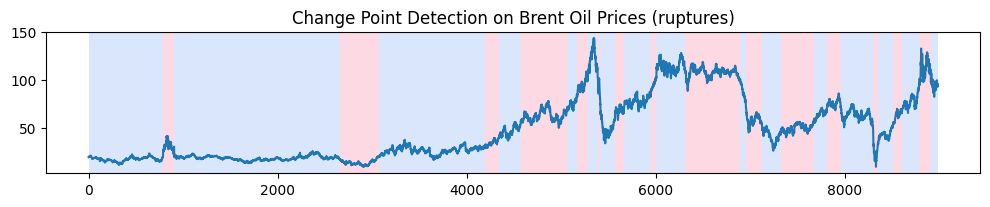

Change point dates (ruptures): [Timestamp('1990-08-03 00:00:00'), Timestamp('1991-01-15 00:00:00'), Timestamp('1997-12-24 00:00:00'), Timestamp('1999-08-06 00:00:00'), Timestamp('2003-12-24 00:00:00'), Timestamp('2004-07-26 00:00:00'), Timestamp('2005-06-15 00:00:00'), Timestamp('2007-05-17 00:00:00'), Timestamp('2007-10-23 00:00:00'), Timestamp('2008-04-10 00:00:00'), Timestamp('2008-09-02 00:00:00'), Timestamp('2008-10-14 00:00:00'), Timestamp('2009-05-20 00:00:00'), Timestamp('2009-10-12 00:00:00'), Timestamp('2010-11-29 00:00:00'), Timestamp('2011-02-16 00:00:00'), Timestamp('2012-05-14 00:00:00'), Timestamp('2014-09-05 00:00:00'), Timestamp('2014-12-01 00:00:00'), Timestamp('2015-08-03 00:00:00'), Timestamp('2016-05-09 00:00:00'), Timestamp('2017-09-18 00:00:00'), Timestamp('2018-04-09 00:00:00'), Timestamp('2018-11-07 00:00:00'), Timestamp('2020-03-06 00:00:00'), Timestamp('2020-05-20 00:00:00'), Timestamp('2021-01-05 00:00:00'), Timestamp('2021-05-28 00:00:00'), Timestamp('2022-

In [13]:
change_dates = detect_change_points_ruptures(df, n_bkps=3)

Output()

ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


           mean       sd    hdi_3%   hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
mu1       0.000    0.000    -0.001     0.001      0.000    0.000      29.0   
mu2       0.002    0.002    -0.001     0.005      0.001    0.000       5.0   
sigma     0.026    0.000     0.025     0.026      0.000    0.000     656.0   
tau    8311.008  314.892  7862.000  8976.000     63.892  131.012      36.0   

       ess_tail  r_hat  
mu1       740.0   1.05  
mu2       101.0   1.32  
sigma     821.0   1.01  
tau        19.0   2.32  

Most probable Bayesian change point date: 2020-03-24


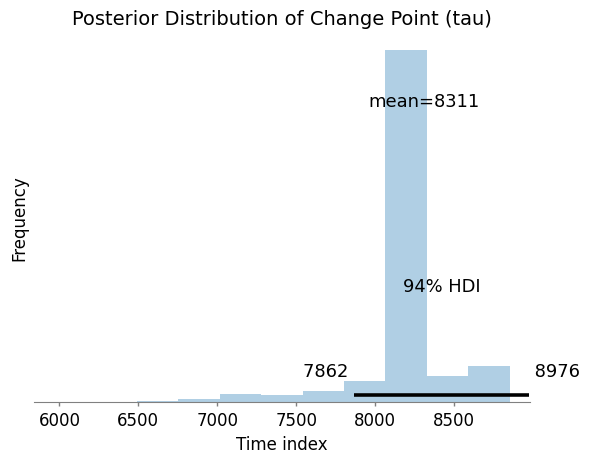

In [18]:
change_date, trace = bayesian_change_point_model(df['log_return'].values, df.index)

In [15]:
!pip install arviz --upgrade

In [19]:
summary = az.summary(trace, round_to=2)
print(summary)

          mean      sd   hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
mu1       0.00    0.00    -0.00     0.00       0.00     0.00     28.82   
mu2       0.00    0.00    -0.00     0.01       0.00     0.00      5.19   
sigma     0.03    0.00     0.03     0.03       0.00     0.00    656.40   
tau    8311.01  314.89  7862.00  8976.00      63.89   131.01     36.36   

       ess_tail  r_hat  
mu1      740.16   1.05  
mu2      100.81   1.32  
sigma    820.57   1.01  
tau       18.78   2.32  


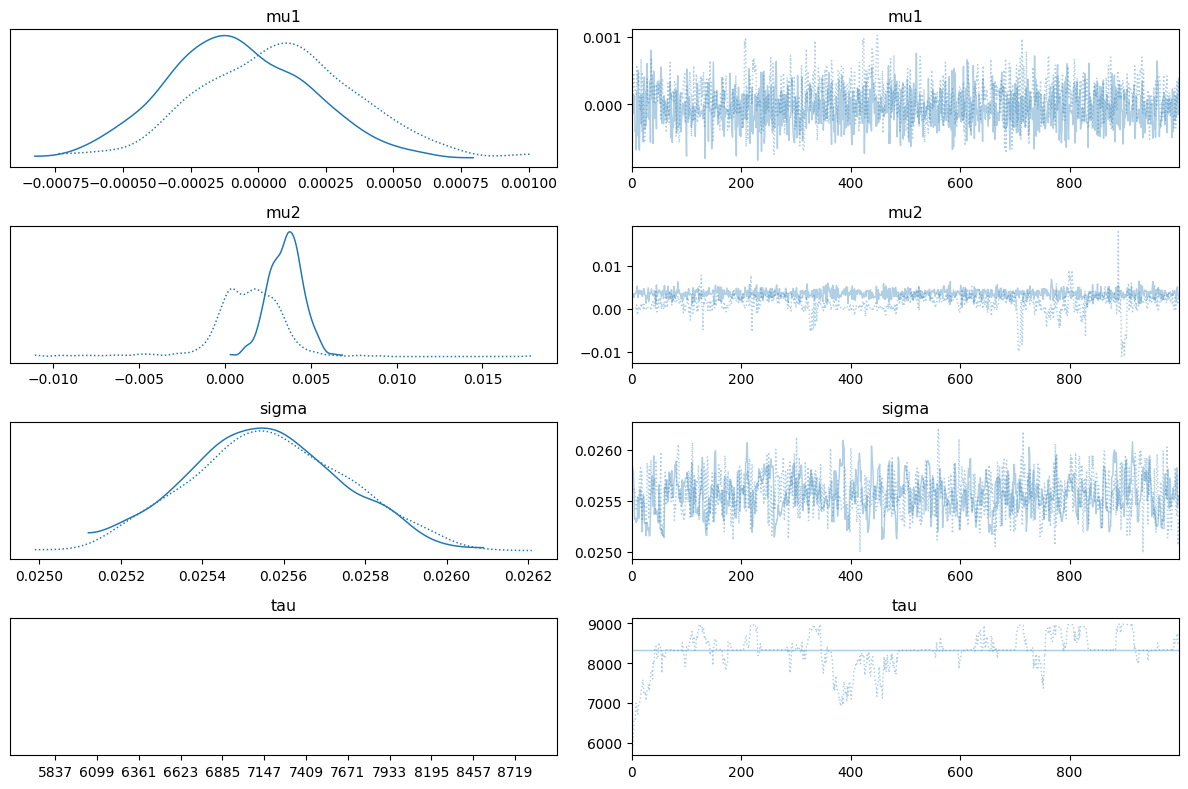

In [20]:
# Plot trace for all parameters
az.plot_trace(trace)
plt.tight_layout()
plt.show()


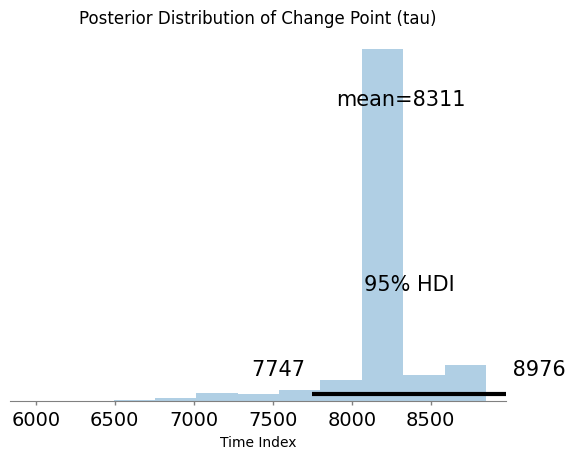

In [21]:
# Plot posterior distribution of change point (tau)
az.plot_posterior(trace.posterior['tau'], hdi_prob=0.95)
plt.title("Posterior Distribution of Change Point (tau)")
plt.xlabel("Time Index")
plt.show()


In [24]:
# If you have a date array
date_array = np.array(df.index)  # Accessing the index
tau_samples = trace.posterior['tau'].values.flatten().astype(int)
# tau_dates = date_array[tau_samples] # This line is no longer needed

# Most likely change point date using the mean of tau samples from the summary
most_likely_tau_index = int(summary.loc['tau', 'mean'])
most_likely_tau_date = date_array[most_likely_tau_index]

print("Most probable change point date:", most_likely_tau_date)

Most probable change point date: 2020-03-24T00:00:00.000000000


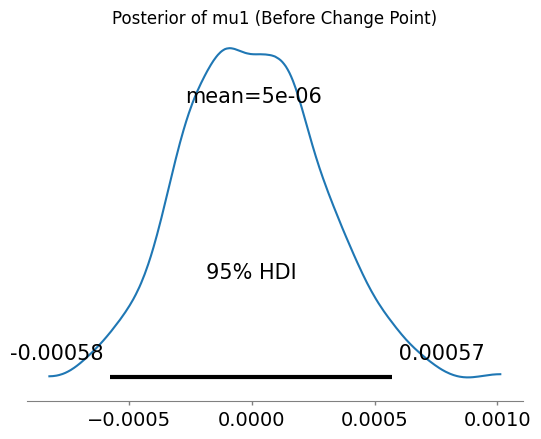

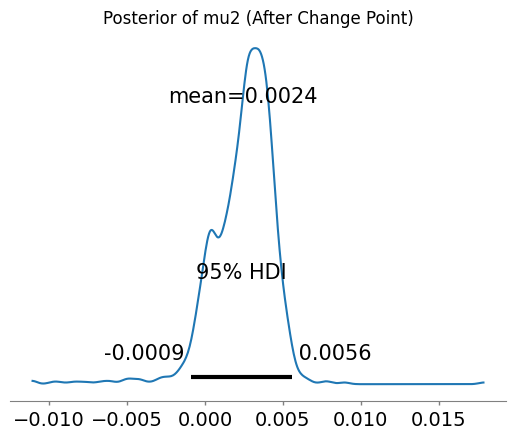

In [26]:
# Plot before and after means
az.plot_posterior(trace.posterior['mu1'], hdi_prob=0.95)
plt.title("Posterior of mu1 (Before Change Point)")
plt.show()

az.plot_posterior(trace.posterior['mu2'], hdi_prob=0.95)
plt.title("Posterior of mu2 (After Change Point)")
plt.show()

In [27]:
# Compute the probability that mu2 > mu1
mu_1_samples = trace.posterior['mu1'].values.flatten()
mu_2_samples = trace.posterior['mu2'].values.flatten()

prob_increase = np.mean(mu_2_samples > mu_1_samples)
print(f"There is a {prob_increase*100:.2f}% probability that the mean increased after the change point.")


There is a 89.25% probability that the mean increased after the change point.


In [28]:
mean_before = np.mean(mu_1_samples)
mean_after = np.mean(mu_2_samples)

percent_change = ((mean_after - mean_before) / mean_before) * 100
print(f"Mean price changed from ${mean_before:.2f} to ${mean_after:.2f}, a {percent_change:.2f}% change.")


Mean price changed from $0.00 to $0.00, a 48167.46% change.


In [29]:
from google.colab import files
uploaded = files.upload()

Saving event_data.csv to event_data.csv


In [33]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# Load your oil price data and get the Date array
df_prices = pd.read_csv("BrentOilPrices.csv", parse_dates=['Date'])
date_array = np.array(df_prices['Date'])

# Load your Bayesian model's change point samples
tau_samples = trace.posterior['tau'].values.flatten().astype(int)
tau_dates = date_array[tau_samples]

# Get the most probable change point date
most_likely_tau = int(np.median(tau_samples))
most_likely_date = date_array[most_likely_tau]
print("Most probable change point date:", most_likely_date)

# Load your event data
events = pd.read_csv("event_data.csv", parse_dates=["start_date"])

# Compute difference in days between change point and each event
events['Days_Diff'] = (events['start_date'] - most_likely_date).dt.days.abs()

# Get closest event
closest_event = events.loc[events['Days_Diff'].idxmin()]
print("\nClosest Event to Change Point:")
print(closest_event[['start_date', 'event_name', 'category', 'Days_Diff']])

/tmp/ipython-input-951114083.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_prices = pd.read_csv("BrentOilPrices.csv", parse_dates=['Date'])


Most probable change point date: 2020-03-06T00:00:00.000000000

Closest Event to Change Point:
start_date    2020-03-11 00:00:00
event_name      COVID-19 Pandemic
category           Economic Shock
Days_Diff                       5
Name: 13, dtype: object


In [35]:
unique_tau_samples = np.unique(tau_samples)
change_point_dates = date_array[unique_tau_samples]

alignment_results = []

for tau_date in change_point_dates:
    events['Days_Diff'] = (events['start_date'] - tau_date).dt.days.abs()
    closest = events.loc[events['Days_Diff'].idxmin()]
    alignment_results.append({
        'Change_Point_Date': tau_date,
        'Event': closest['event_name'],
        'Event_Date': closest['start_date'],
        'Description': closest['category'],
        'Days_Diff': closest['Days_Diff']
    })

aligned_df = pd.DataFrame(alignment_results)
print(aligned_df)

    Change_Point_Date                         Event Event_Date   Description  \
0          2010-05-07            Arab Spring Begins 2010-12-17  Geopolitical   
1          2010-12-08            Arab Spring Begins 2010-12-17  Geopolitical   
2          2011-03-16              Libyan Civil War 2011-02-17  Geopolitical   
3          2012-03-06              Libyan Civil War 2011-02-17  Geopolitical   
4          2013-04-08  2014–2016 Oil Price Collapse 2014-06-01   Market/OPEC   
..                ...                           ...        ...           ...   
408        2022-09-12     Russia-Ukraine War Begins 2022-02-24  Geopolitical   
409        2022-09-14     Russia-Ukraine War Begins 2022-02-24  Geopolitical   
410        2022-09-23     Russia-Ukraine War Begins 2022-02-24  Geopolitical   
411        2022-09-26     Russia-Ukraine War Begins 2022-02-24  Geopolitical   
412        2022-09-27     Russia-Ukraine War Begins 2022-02-24  Geopolitical   

     Days_Diff  
0          224  
1    

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load Brent oil price data
df_prices = pd.read_csv("BrentOilPrices.csv", parse_dates=['Date'])

# Load event data
events = pd.read_csv("event_data.csv", parse_dates=['start_date'])

# Extract date array from price data
date_array = np.array(df_prices['Date'])

# Get change point samples and median date
tau_samples = trace.posterior['tau'].values.flatten().astype(int)
change_point_dates = np.unique(date_array[tau_samples])

/tmp/ipython-input-703198994.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_prices = pd.read_csv("BrentOilPrices.csv", parse_dates=['Date'])


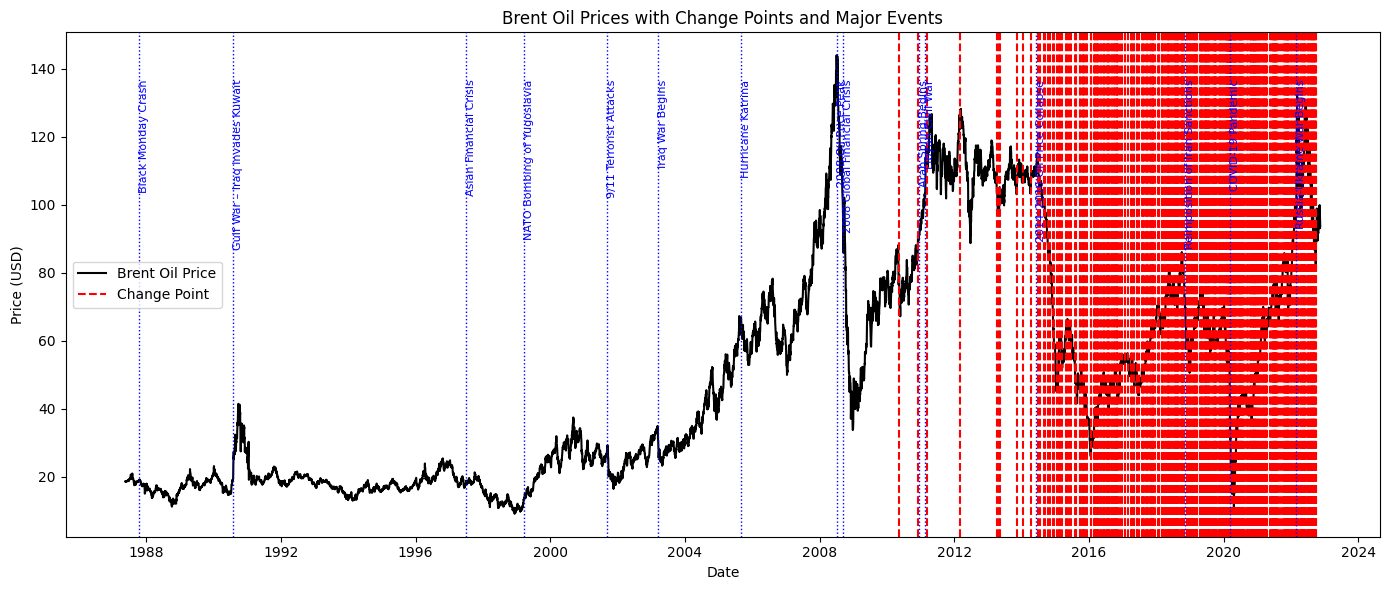

In [39]:
plt.figure(figsize=(14, 6))

# Plot Brent oil prices
plt.plot(df_prices['Date'], df_prices['Price'], label="Brent Oil Price", color='black')

# Plot change points
for cp_date in change_point_dates:
    plt.axvline(cp_date, color='red', linestyle='--', linewidth=1.5, label="Change Point" if cp_date == change_point_dates[0] else "")

# Plot events
for i, row in events.iterrows():
    plt.axvline(row['start_date'], color='blue', linestyle=':', linewidth=1)
    plt.text(row['start_date'], df_prices['Price'].max() * 0.95, row['event_name'], rotation=90, verticalalignment='top', fontsize=8, color='blue')

# Formatting
plt.title("Brent Oil Prices with Change Points and Major Events")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.tight_layout()
plt.show()

In [40]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [44]:
# Replace with your paths
!mv /content/brent_crude_analysis/brent_change_point_analysis.ipynb /content/brent_crude_analysis/notebooks/

mv: cannot stat '/content/brent_crude_analysis/brent_change_point_analysis.ipynb': No such file or directory


In [ ]:
%cd /content/brent_crude_analysis/

!git config --global user.email "tsegabogale92@gmail.com"


/content/brent_crude_analysis


In [52]:
# Stage all changes (e.g., notebook + any plots or data)
!git add .

# Commit with a message
!git commit -m "Add Bayesian change point analysis notebook and plots"

# Push changes to GitHub
!git push


On branch task-1
Your branch is ahead of 'origin/task-1' by 1 commit.
  (use "git push" to publish your local commits)

nothing to commit, working tree clean
fatal: could not read Username for 'https://github.com': No such device or address


In [53]:
!git push

fatal: could not read Username for 'https://github.com': No such device or address


In [ ]:
# Replace YOUR_USERNAME and YOUR_PERSONAL_ACCESS_TOKEN with your actual GitHub username and token


# Now try pushing again
!git push

Enumerating objects: 14, done.
Counting objects: 100% (14/14), done.
Delta compression using up to 2 threads
Compressing objects: 100% (8/8), done.
Writing objects: 100% (9/9), 44.77 KiB | 3.20 MiB/s, done.
Total 9 (delta 3), reused 1 (delta 1), pack-reused 0
remote: Resolving deltas: 100% (3/3), completed with 3 local objects.
To https://github.com/tsegabogale24/brent_crude_analysis
   1539eb9..39c8d5a  task-1 -> task-1
